# CAFA-5 K-mer Data Preprocessing

This notebook prepares CAFA-5 protein data for downstream machine learning.

## Goals
- Load protein sequences and GO annotations
- Remove missing labels
- Remove empty sequences
- Remove sequences containing non-standard amino acids
- Align sequences with labels
- Encode multi-label GO targets
- Filter rare GO terms
- Build k-mer frequency features
- Split into training and validation sets
- Standardize features
- Save processed outputs for model training

## 1. Import libraries and define file paths

In [1]:
import os
import pickle
from itertools import product

import numpy as np
import pandas as pd
from Bio import SeqIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from scipy.sparse import csr_matrix, save_npz
import matplotlib.pyplot as plt

In [4]:
# Update this path if your CAFA-5 folder lives somewhere else
BASE_DIR = "../../cafa-5-protein-function-prediction"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")

train_fasta_path = os.path.join(TRAIN_DIR, "train_sequences.fasta")
train_terms_path = os.path.join(TRAIN_DIR, "train_terms.tsv")
train_taxonomy_path = os.path.join(TRAIN_DIR, "train_taxonomy.tsv")

for p in [train_fasta_path, train_terms_path, train_taxonomy_path]:
    print(p, "->", os.path.exists(p))

../cafa-5-protein-function-prediction/Train/train_sequences.fasta -> True
../cafa-5-protein-function-prediction/Train/train_terms.tsv -> True
../cafa-5-protein-function-prediction/Train/train_taxonomy.tsv -> True


## 2. Load raw data

In [5]:
# Load sequences from FASTA
sequences_dict = {}
duplicate_id_count = 0
missing_id_count = 0
empty_seq_count = 0

for record in SeqIO.parse(train_fasta_path, "fasta"):
    seq_id = record.id
    seq = str(record.seq).strip()

    if not seq_id:
        missing_id_count += 1
        continue

    if seq_id in sequences_dict:
        duplicate_id_count += 1

    if len(seq) == 0:
        empty_seq_count += 1

    sequences_dict[seq_id] = seq

print("Raw sequences loaded:", len(sequences_dict))
print("Duplicate FASTA IDs:", duplicate_id_count)
print("Missing IDs:", missing_id_count)
print("Empty sequences:", empty_seq_count)

# Load labels and taxonomy
terms = pd.read_csv(train_terms_path, sep="\t")
taxonomy = pd.read_csv(train_taxonomy_path, sep="\t")

print("train_terms shape:", terms.shape)
print("train_taxonomy shape:", taxonomy.shape)
terms.head()

Raw sequences loaded: 142246
Duplicate FASTA IDs: 0
Missing IDs: 0
Empty sequences: 0
train_terms shape: (5363863, 3)
train_taxonomy shape: (142246, 2)


,EntryID,term,aspect
0,A0A009IHW8,GO:0008152,BPO
1,A0A009IHW8,GO:0034655,BPO
2,A0A009IHW8,GO:0072523,BPO
3,A0A009IHW8,GO:0044270,BPO
4,A0A009IHW8,GO:0006753,BPO


## 3. Check missing values

In [6]:
print("Missing values in train_terms:")
print(terms.isnull().sum())
print()

print("Missing values in train_taxonomy:")
print(taxonomy.isnull().sum())

Missing values in train_terms:
EntryID    0
term       0
aspect     0
dtype: int64

Missing values in train_taxonomy:
EntryID       0
taxonomyID    0
dtype: int64


In [7]:
# Remove missing values in the label table
terms = terms.dropna(subset=["EntryID", "term"]).copy()
print("train_terms shape after dropping missing EntryID/term rows:", terms.shape)

train_terms shape after dropping missing EntryID/term rows: (5363863, 3)


## 4. Remove invalid sequences

We remove:
- empty sequences
- sequences containing non-standard amino acids

Standard amino acids:
`ACDEFGHIKLMNPQRSTVWY`

In [8]:
valid_aas = set("ACDEFGHIKLMNPQRSTVWY")

clean_sequences_dict = {}
removed_empty_ids = []
removed_invalid = []   # (protein_id, bad_chars)

for seq_id, seq in sequences_dict.items():
    seq = seq.strip()

    if len(seq) == 0:
        removed_empty_ids.append(seq_id)
        continue

    bad = set(seq) - valid_aas
    if bad:
        removed_invalid.append((seq_id, bad))
        continue

    clean_sequences_dict[seq_id] = seq

print("Removed empty sequences:", len(removed_empty_ids))
print("Removed invalid sequences:", len(removed_invalid))
print("Remaining clean sequences:", len(clean_sequences_dict))

Removed empty sequences: 0
Removed invalid sequences: 1677
Remaining clean sequences: 140569


In [9]:
# Show a few removed invalid sequences
removed_invalid[:10]

[('Q86KP5', {'U'}),
 ('O93661', {'O'}),
 ('Q9JLT4', {'U'}),
 ('Q8FDI4', {'X'}),
 ('P11145', {'X'}),
 ('P86782', {'X'}),
 ('P18173', {'U'}),
 ('P80473', {'X'}),
 ('P80803', {'X'}),
 ('P84712', {'X'})]

In [10]:
# Replace the raw dictionary with the cleaned one
sequences_dict = clean_sequences_dict

## 5. Basic sequence statistics

In [11]:
lengths = [len(seq) for seq in sequences_dict.values()]

print("Number of proteins:", len(sequences_dict))
print("Mean length:", np.mean(lengths))
print("Median length:", np.median(lengths))
print("Min length:", np.min(lengths))
print("Max length:", np.max(lengths))
print("Std length:", np.std(lengths))

Number of proteins: 140569
Mean length: 553.7165946972661
Median length: 412.0
Min length: 3
Max length: 35375
Std length: 639.6512065166373


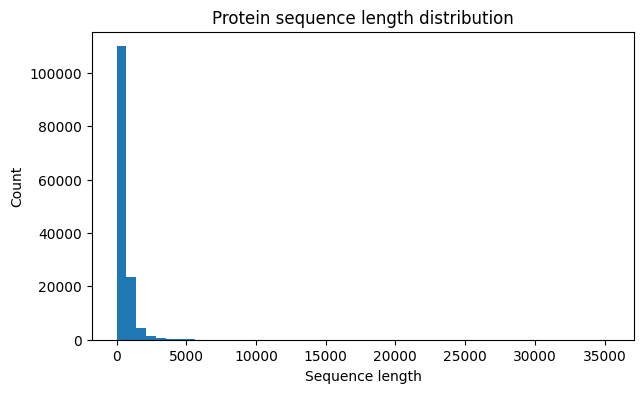

In [12]:
plt.figure(figsize=(7, 4))
plt.hist(lengths, bins=50)
plt.xlabel("Sequence length")
plt.ylabel("Count")
plt.title("Protein sequence length distribution")
plt.show()

## 6. Build label dictionary and align sequences with labels

In [13]:
labels_dict = terms.groupby("EntryID")["term"].apply(list)

sequence_ids = set(sequences_dict.keys())
label_ids = set(labels_dict.index)

print("Proteins with sequence only:", len(sequence_ids - label_ids))
print("Proteins with label only:", len(label_ids - sequence_ids))
print("Proteins with both:", len(sequence_ids & label_ids))

Proteins with sequence only: 0
Proteins with label only: 1677
Proteins with both: 140569


In [14]:
protein_ids = []
sequences = []
all_labels = []

for pid, seq in sequences_dict.items():
    if pid in labels_dict:
        protein_ids.append(pid)
        sequences.append(seq)
        all_labels.append(labels_dict[pid])

print("Aligned proteins retained:", len(sequences))

Aligned proteins retained: 140569


## 7. Multi-label encoding

In [15]:
mlb = MultiLabelBinarizer(sparse_output=True)
Y_sparse = mlb.fit_transform(all_labels)

print("Y_sparse shape:", Y_sparse.shape, flush=True)

Y_sparse shape: (140569, 31454)


In [16]:
used_go_terms = set()

for labels in all_labels:
    used_go_terms.update(labels)

print("Number of GO used:", len(used_go_terms))

Number of GO used: 31454


In [17]:
used_go_terms = set()

for labels in all_labels:
    used_go_terms.update(labels)

print("Number of GO used:", len(used_go_terms))

Number of GO used: 31454


In [18]:
terms_clean_go = terms[terms["term"].isin(used_go_terms)]
aspect_dict = terms_clean_go.set_index("term")["aspect"].to_dict()
print(list(used_go_terms)[:20])
print("Total GO after cleaning:", len(used_go_terms))

['GO:0001696', 'GO:0008645', 'GO:0005901', 'GO:0072089', 'GO:0061824', 'GO:0010882', 'GO:0050270', 'GO:0019941', 'GO:0002509', 'GO:0008445', 'GO:1990536', 'GO:0045620', 'GO:0006681', 'GO:0038047', 'GO:2000980', 'GO:1990527', 'GO:0048796', 'GO:0034464', 'GO:0035180', 'GO:0030200']
Total GO after cleaning: 31454


| namespace          | category  |
| ------------------ | --- |
| biological_process | BPO |
| molecular_function | MFO |
| cellular_component | CCO |


BPO    21279
MFO     7218
CCO     2957
Name: count, dtype: int64


<Axes: >

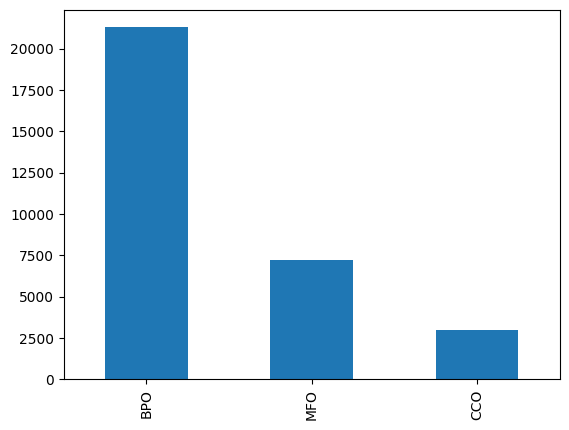

In [19]:
aspect_series = pd.Series([
    aspect_dict.get(go, "Unknown") for go in used_go_terms
])

print(aspect_series.value_counts())
aspect_series.value_counts().plot(kind="bar")

## 9. Build k-mer features

In [20]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
k = 2

kmer_vocab = [''.join(p) for p in product(amino_acids, repeat=k)]
kmer_to_idx = {kmer: i for i, kmer in enumerate(kmer_vocab)}

print("k =", k)
print("Number of k-mers in vocabulary:", len(kmer_vocab))

k = 2
Number of k-mers in vocabulary: 400


In [21]:
def seq_to_kmer_vector(seq, kmer_to_idx, k=2):
    vec = np.zeros(len(kmer_to_idx), dtype=np.float32)

    if len(seq) < k:
        return vec

    total = len(seq) - k + 1

    for i in range(total):
        kmer = seq[i:i+k]
        if kmer in kmer_to_idx:
            vec[kmer_to_idx[kmer]] += 1.0

    vec /= total
    return vec

In [22]:
X = np.array(
    [seq_to_kmer_vector(seq, kmer_to_idx, k=k) for seq in sequences],
    dtype=np.float32
)

print("X shape:", X.shape)

X shape: (140569, 400)


## 10. Split into training and validation sets

In [25]:
indices = np.arange(len(X))

# Step 1: cut test（15%）
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.15,
    random_state=42
)

# Step 2: cut val from remain 85%（15% of total = 0.15 / 0.85）
val_ratio = 0.15 / 0.85

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=val_ratio,
    random_state=42
)

X_train = X[train_idx]
X_val = X[val_idx]
X_test = X[test_idx]

Y_train = Y_sparse[train_idx]
Y_val = Y_sparse[val_idx]
Y_test = Y_sparse[test_idx]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("Y_train:", Y_train.shape)
print("Y_val:", Y_val.shape)
print("Y_test:", Y_test.shape)

X_train: (98397, 400)
X_val: (21086, 400)
X_test: (21086, 400)
Y_train: (98397, 31454)
Y_val: (21086, 31454)
Y_test: (21086, 31454)


## 11. Standardize features

In [26]:
scaler = StandardScaler()

# fit only on train
X_train = scaler.fit_transform(X_train).astype(np.float32)

# apply same scaler to val/test
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print("X_train dtype:", X_train.dtype)
print("X_val dtype:", X_val.dtype)
print("X_test dtype:", X_test.dtype)

X_train dtype: float32
X_val dtype: float32
X_test dtype: float32


## 12. Save processed outputs

In [30]:
from scipy.sparse import save_npz

OUTPUT_DIR = "data_processed_kmer_70"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# save X
np.save(os.path.join(OUTPUT_DIR, "X_train.npy"), X_train)
np.save(os.path.join(OUTPUT_DIR, "X_val.npy"), X_val)
np.save(os.path.join(OUTPUT_DIR, "X_test.npy"), X_test)

# save sparse Y
save_npz(os.path.join(OUTPUT_DIR, "Y_train.npz"), Y_train)
save_npz(os.path.join(OUTPUT_DIR, "Y_val.npz"), Y_val)
save_npz(os.path.join(OUTPUT_DIR, "Y_test.npz"), Y_test)

# save split indices
np.save(os.path.join(OUTPUT_DIR, "train_idx.npy"), train_idx)
np.save(os.path.join(OUTPUT_DIR, "val_idx.npy"), val_idx)
np.save(os.path.join(OUTPUT_DIR, "test_idx.npy"), test_idx)

# save metadata
with open(os.path.join(OUTPUT_DIR, "meta.pkl"), "wb") as f:
    pickle.dump({
        "protein_ids": protein_ids,
        "go_terms": mlb.classes_
    }, f)

print("Saved processed files to:", OUTPUT_DIR)
print(os.listdir(OUTPUT_DIR))

Saved processed files to: data_processed_kmer_70
['.ipynb_checkpoints', 'X_test.npy', 'X_train.npy', 'X_val.npy', 'Y_test.npy.npz', 'Y_test.npz', 'Y_train.npz', 'Y_val.npz', 'meta.pkl', 'test_idx.npy', 'train_idx.npy', 'val_idx.npy']


## 13. Summary

This notebook completed:
- missing-value checks
- removal of empty sequences
- removal of sequences with invalid amino acids
- sequence-label alignment
- multi-label GO encoding
- rare GO term filtering
- k-mer feature extraction
- train/validation split
- feature standardization
- saving reusable processed outputs